En este archivo Notebook realizo diferentes implementaciones del proyecto para poder ejecutarlas por bloques y obtener un resultado visual

In [12]:
# Añadimos todas las librerias necesarias
import oracledb as oracledb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pdfplumber

Creación de la conexión a la base de datos

In [18]:
# Crear el DSN usando la IP remota
dsn = oracledb.makedsn("afrodita.lcc.uma.es", 1521, sid="APOLO")

# Conectarse
conn = oracledb.connect(user="tfm_puertas", password="JCGRmlbEsc", dsn=dsn)

# Ejecutar consulta
cur = conn.cursor()
cur.execute("select count(*) from v_calificaciones")
for row in cur:
    print(row)

cur.close()

(96914,)


PARA LA REUNIÓN, POR QUÉ LA MEDIA ESTABA DANDO PROBLEMAS

In [14]:
cur = conn.cursor()
cur.execute("""
            SELECT nombreasignatura, NUM_CALIFICACIÓN
            FROM v_calificaciones
            WHERE codigoalum = 'B30A2DCB567D8E3120A3E33582F98B90'
            """)
for row in cur:
    print(row)

(None, '0')
(None, '0')
(None, '7')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '3')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '3')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '3')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')
(None, '0')


Hay alumnos en la base de datos que apenas tienen asignaturas aprobadas, ya sea porque es asi o porque la información no está completa, por lo que los voy a descartar de la comprobación

Función que calcula la nota media ponderada.

Nota media ponderada: Media de todas las asignaturas aprobadas por el número de créditos que valen, dividido entre el total de créditos de la titulación

In [4]:
def obtener_nota_alumno(id:str):
    cur = conn.cursor()
    cur.execute("""
        SELECT NOMBREASIGNATURA, NUM_CALIFICACIÓN
        FROM (
            SELECT 
            CODIGOALUM,
            NOMBREASIGNATURA,
            NUM_CALIFICACIÓN,
            ROW_NUMBER() OVER (
                PARTITION BY CODIGOALUM, NOMBREASIGNATURA 
                ORDER BY NUM_CALIFICACIÓN DESC
            ) AS rn
            FROM v_calificaciones
            WHERE 
                (NOMBREASIGNATURA IS NOT NULL 
                OR NUM_CALIFICACIÓN IS NOT NULL)
            )
        WHERE CODIGOALUM = :codigo AND rn = 1
            """, codigo = id)
    resultado = cur.fetchall()
    for row in resultado:
        print(row)
    
print(obtener_nota_alumno('0208F18506E41D3F29A4CAAD842FD0FA'))
        
  


('Administración de Bases de Datos', '5')
('Administración de Sistemas Operativos', '5')
('Análisis y Diseño de Algoritmos', '0')
('Arquitecturas Virtuales', '5')
('Bases de Datos', '5')
('Cálculo para la Computación', '0')
('Desarrollo de Servicios Telemáticos', '5')
('Diseño y Evaluación de Infraestructuras Informáticas', '5')
('Electrónica Digital', '5')
('Electrónica para Domótica', '0')
('Estructura de Computadores', '6')
('Estructura de Datos', '0')
('Estructuras Algebraicas para la Computación', '0')
('Fundamentos de Electrónica', '5')
('Fundamentos de la Programación', '5')
('Fundamentos Físicos de la Informática', '5')
('Introducción a la Ingeniería del Software', '6')
('Introducción a los Sistemas de Información', '6')
('Matemática Discreta', '1')
('Métodos Estadísticos para la Computación', '2')
('Modelos Estadísticos y Simulación', '7')
('Organización Empresarial', '6')
('Planificación de Proyectos y Análisis de Riesgos', '4')
('Procesadores de Lenguajes', '0')
('Programaci

In [11]:
def calcular_media_ponderada(conn, codigo_alumno, curso_max):
    with conn.cursor() as cur: 
        cur.execute("""
            SELECT 
                AVG(TO_NUMBER(NUM_CALIFICACIÓN)) AS media_aprobadas,
                COUNT(*) AS asignaturas_aprobadas,
                SUM(CREDITOS) AS creditos_aprobados
            FROM v_calificaciones
            WHERE CODIGOALUM = :codigo
            AND CALIFICACIÓN NOT IN ('NO PRESENTADO', 'SUSPENSO')
            AND TO_NUMBER(SUBSTR(CURSOACADÉMICO, 1, 4)) < TO_NUMBER(SUBSTR(:curso_inicio , 1, 4))
        """, codigo=codigo_alumno, curso_inicio=curso_max[:4])

        resultado = cur.fetchone() #Como esperamos solo un resultado, uso fetchone
        media, aprobadas, creditos = resultado

        if media is None or aprobadas == 0:
            return (None, 0)  # Evitamos división por cero o falta de datos

        ponderada = (media * creditos) / 240
        return (round(ponderada, 2), aprobadas) #CAMBIO: Devuelvo también la cantidad de aprobadas
    
calcular_media_ponderada(conn, '0208F18506E41D3F29A4CAAD842FD0FA','2020-21')


AttributeError: 'NoneType' object has no attribute 'send'

Dada una asignatura, obtener todos los alumnos que la han cursado, y el curso académico en el que lo hicieron

In [6]:
def obtener_alumnos_matriculados(conn, nombre_asignatura):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT DISTINCT CODIGOALUM, CURSOACADÉMICO
            FROM v_calificaciones
            WHERE REPLACE(NOMBREASIGNATURA, ' ', '') = :asignatura
        """, asignatura=nombre_asignatura)

        return cur.fetchall()
        
obtener_alumnos_matriculados(conn, 'VisiónporComputador')


[('E7AC1E0B6F38D865A51141CEAA6AABDC', '2018-19'),
 ('0154E5C78A6179BDB090C06DEC095A17', '2018-19'),
 ('7334688E1698AECCCB5C2693A55E91DB', '2019-20'),
 ('09D3DA93C1195F9337C98092057E86BE', '2019-20'),
 ('56D2035062EF09C99B875AF14B6DBAEF', '2019-20'),
 ('F2D77DDA93F07980CDAFA4FC9B49B81F', '2020-21'),
 ('E475FCF6F6FB2F4200647487CBBA367B', '2020-21'),
 ('E8C0BD34336D34FB3D50886305A9DE12', '2020-21'),
 ('592AEBD3C172B1FF1B0017D1296ED7E8', '2021-22'),
 ('9475ED7552FA67FD81C807CACB4497F4', '2021-22'),
 ('B532D6CA33EAE40DB254D225231E4986', '2022-23'),
 ('B4A95BD04DD3E641CBDF84E3F3416C64', '2022-23'),
 ('8FAB2C4EDCA1484446405F73B2EC2026', '2022-23'),
 ('7114F27ECC34C1E75F8557E099343544', '2020-21'),
 ('6D4F20745BAB50857886AAD4AFD339D5', '2021-22'),
 ('47BA4947D4B7CE8520F27723ABC03B29', '2020-21'),
 ('43ECD972302EE21A6B0ECCBB67940670', '2018-19'),
 ('D7F78EB38BBCCC219CC12770E0CCD213', '2018-19'),
 ('8E14F1B5DE2DEEC5FED6D376A2A53E72', '2019-20'),
 ('E08B5D4B37BF613FDA0E9D477207702C', '2019-20'),


Calcular nota de corte de cada año

Nota de corte: La nota media ponderada más baja que está matriculado en la asignatura hasta el año anterior de la matrícula

In [10]:
def calcular_nota_corte(conn, nombre_asignatura):
    # 1. Obtener alumnos + curso académico donde cursaron esa asignatura
    alumnos_con_curso = obtener_alumnos_matriculados(conn, nombre_asignatura)

    # 2. Agrupar alumnos por curso académico
    cursos = {}
    for codigo_alum, curso_acad in alumnos_con_curso:
        cursos.setdefault(curso_acad, []).append(codigo_alum)

    # 3. Para cada curso, calcular la nota de corte
    nota_corte_por_año = {}

    for curso_acad, codigos_alumnos in cursos.items():
        medias = []
        for codigo_alum in codigos_alumnos:
            resultado = calcular_media_ponderada(conn, codigo_alum, curso_acad)
            if resultado:
                media, aprobadas = resultado
                if media is not None and aprobadas > 10:
                    print(media, ',', codigo_alum)
                    medias.append(media)
        if medias:
            nota_corte_por_año[curso_acad] = min(medias)

    return nota_corte_por_año  # Dict: { "2018-19": 6.25, "2019-20": 5.8, ... }

calcular_nota_corte(conn, 'VisiónporComputador')


DatabaseError: DPY-4011: the database or network closed the connection
[WinError 10054] Se ha forzado la interrupción de una conexión existente por el host remoto
Help: https://python-oracledb.readthedocs.io/en/latest/user_guide/troubleshooting.html#dpy-4011

Cálculo de la probabilidad de entrada: Dada la nota de corte de cada año, el porcentaje de años en los que habría entrado en la asignatura

In [8]:
def calcular_probabilidad_entrada(conn, nombre_asignatura, codigo_alumno):
    # Obtener las notas de corte por año
    notas_corte = calcular_nota_corte(conn, nombre_asignatura)
    print(notas_corte)

    if not notas_corte:
        return 0.0  # No hay base para calcular probabilidad

    total = 0
    supera = 0

    media_alumno, aprobadas = calcular_media_ponderada(conn, codigo_alumno, '2022-23')
    print(media_alumno)
    #media_alumno = 0.15
    for curso_acad, nota_corte in notas_corte.items():
        
        if media_alumno is not None:
            total += 1
            if media_alumno > nota_corte:
                supera += 1

    if total == 0:
        return 0.0  # El alumno no tiene historial válido

    probabilidad = (supera / total) * 100
    return round(probabilidad, 2)

calcular_probabilidad_entrada(conn, 'VisiónporComputador', '0208F18506E41D3F29A4CAAD842FD0FA')


1.9 , B6F470F0C52335228D8AA2A351BF94D9
3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.33 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55DC
2.6 , 9C4267569C9FF29620C3084FAB122899
2.2 , CA6E

100.0

Crear un DataFrame a través de una consulta

In [9]:
def crear_df(conn):

    sql = """SELECT CODIGOALUM, REPLACE(NOMBREASIGNATURA, ' ', '') AS NOMBREASIGNATURA, NUM_CALIFICACIÓN
FROM (
    SELECT 
        CODIGOALUM,
        REPLACE(NOMBREASIGNATURA, ' ', '') AS NOMBREASIGNATURA,
        NUM_CALIFICACIÓN,
        ROW_NUMBER() OVER (
            PARTITION BY CODIGOALUM, NOMBREASIGNATURA 
            ORDER BY NUM_CALIFICACIÓN DESC
        ) AS rn
    FROM v_calificaciones
    WHERE 
        CODIGOALUM IS NOT NULL 
        OR NOMBREASIGNATURA IS NOT NULL 
        OR NUM_CALIFICACIÓN IS NOT NULL
)
WHERE rn = 1"""
    
    df = pd.read_sql(sql, conn)
    return df

df = crear_df(conn)
print(df)

C:\Users\6003480\AppData\Local\Temp\ipykernel_13352\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


                             CODIGOALUM  \
0      AACA0E4685A6A3B516C207AC2C5355CF   
1      AACA0E4685A6A3B516C207AC2C5355CF   
2      AACA0E4685A6A3B516C207AC2C5355CF   
3      AACA0E4685A6A3B516C207AC2C5355CF   
4      AACA0E4685A6A3B516C207AC2C5355CF   
...                                 ...   
55657  99958A0BA118319B13F58DD6AB051535   
55658  99958A0BA118319B13F58DD6AB051535   
55659  99958A0BA118319B13F58DD6AB051535   
55660  99958A0BA118319B13F58DD6AB051535   
55661  99958A0BA118319B13F58DD6AB051535   

                                NOMBREASIGNATURA NUM_CALIFICACIÓN  
0                   AdministracióndeBasesdeDatos                6  
1                 AdministracióndeRedesySistemas                6  
2                    AnálisisyDiseñodeAlgoritmos                5  
3      AnálisisyDiseñodelosSistemasdeInformación                7  
4                                   BasesdeDatos                5  
...                                          ...              ...  
55657  

Creo el cluster y leo la base de datos del csv para agilizar procesos. Entreno el cluster con una matriz de alumnos x asignaturas

In [10]:
# Suponemos que tienes un DataFrame con columnas: ['CODIGOALUM', 'NOMBREASIGNATURA', 'NUM_CALIFICACIÓN']
#df = pd.read_csv("data.csv")
def entrenar_clustering(df, n_clusters=12):
    # Crear matriz alumno-asignatura
    df['NUM_CALIFICACIÓN'] = pd.to_numeric(df['NUM_CALIFICACIÓN'], errors='coerce')
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN')
    matriz = matriz.fillna(0)  #Para evitar valores NaN
    
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    modelo = KMeans(n_clusters=n_clusters, random_state=42)
    modelo.fit(matriz_escalada)
    
    # Añadir etiquetas de cluster
    df_clusters = pd.DataFrame(matriz.index, columns=['CODIGOALUM'])
    df_clusters['cluster'] = modelo.labels_
    
    return modelo, scaler, matriz, df_clusters

Busco el cluster al que se asemeja el alumno, y ahí comparo las notas para ver la similitud

In [11]:
def predecir_afinidad_cluster(alumno_id, asignatura, modelo, scaler, matriz, df_clusters, df_original):
    if alumno_id not in matriz.index or asignatura not in matriz.columns:
        return None
    
    alumno_vector = scaler.transform(matriz.loc[[alumno_id]])
    cluster_id = modelo.predict(alumno_vector)[0]
    
    # Alumnos en ese cluster
    alumnos_similares = df_clusters[df_clusters['cluster'] == cluster_id]['CODIGOALUM']
    
    # Notas en la asignatura de ese grupo
    notas = df_original[
        (df_original['CODIGOALUM'].isin(alumnos_similares)) &
        (df_original['NOMBREASIGNATURA'] == asignatura) &
        (df_original['NUM_CALIFICACIÓN'].notnull())
    ]['NUM_CALIFICACIÓN'].astype(float)
    
    if notas.empty:
        return 0.0
    
    return round(notas.mean() / 10, 3)


In [12]:
modelo, scaler, matriz, df_clusters = entrenar_clustering(df)
afinidad = predecir_afinidad_cluster('0208F18506E41D3F29A4CAAD842FD0FA', 'VisiónporComputador', modelo, scaler, matriz, df_clusters, df)
print(f"Afinidad estimada: {afinidad}")

Afinidad estimada: 0.38


In [13]:
# Función para construir la matriz de alumnos
def construir_matriz(df):
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN')
    matriz = matriz.fillna(0)
    return matriz

# Método del codo
def metodo_del_codo(matriz, max_k=10):
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(matriz_escalada)
        inercia.append(kmeans.inertia_)
    
    # Graficar el codo
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia (WCSS)')
    plt.title('Método del Codo')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()
    plt.savefig()

    return inercia  # Por si quieres usarla luego


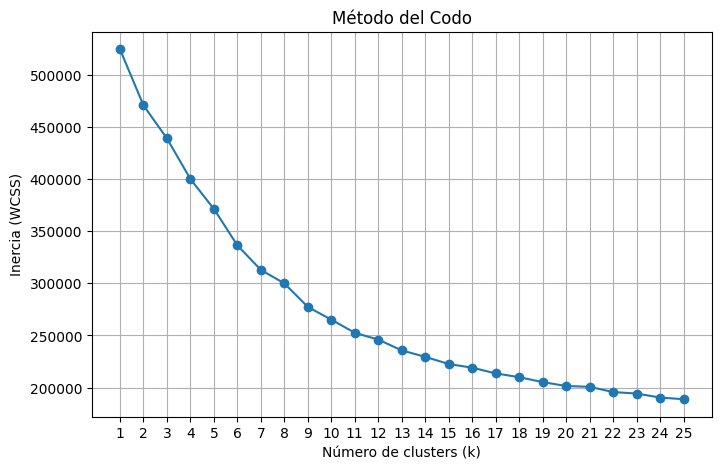

TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

<Figure size 640x480 with 0 Axes>

In [16]:
matriz = construir_matriz(df)
metodo_del_codo(matriz, max_k=25)

Añadir registro al DataFrame

In [14]:
def agregar_calificacion():
    nueva_fila = {
        "CODIGOALUM": "nuevo-alumno",
        "NOMBREASIGNATURA": "VisiónporComputador",
        "NUM_CALIFICACIÓN": "6"
    }
    
    df = crear_df(conn)

    # Agregar y quedarnos solo con la calificación más alta por alumno/asignatura
    df = pd.concat([df, pd.DataFrame([nueva_fila])], ignore_index=True)

    # Simula el ROW_NUMBER() en pandas
    df = (
        df.sort_values("NUM_CALIFICACIÓN", ascending=False)
          .drop_duplicates(subset=["CODIGOALUM", "NOMBREASIGNATURA"], keep="first")
          .reset_index(drop=True)
    )
    
    print(df)

    return {"message": "Calificación agregada exitosamente"}

agregar_calificacion()


C:\Users\jechi\AppData\Local\Temp\ipykernel_11980\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


                             CODIGOALUM                     NOMBREASIGNATURA  \
0      E488839B42828098B4F6BAA3EDE0245A        ProgramaciónOrientadaaObjetos   
1      D272BA2EDCEBC85F0861FEF695B90197                          Estadística   
2      073983F3640D9CA93A69C0AC46ECF0DF                    PrácticasExternas   
3      D2454AF8BF36065AF2B4462971B856F6  ProgramacióndeSistemasyConcurrencia   
4      D2454AF8BF36065AF2B4462971B856F6        ProgramaciónOrientadaaObjetos   
...                                 ...                                  ...   
55658  7EDD225DD39603A6871F1252E54CA1A2                   SistemasOperativos   
55659  C7382D9C0FE0EA0D3E6A79708388526D             EstructuradeComputadores   
55660  7E43DCFB890335693601F637E214A75C                    PrácticasExternas   
55661  C736D3D8B4D8EE14A5F12697EBE2D4C4                   SistemasOperativos   
55662  714E96A0B766DD52A252F9C17C38CC5F                    EstructuradeDatos   

      NUM_CALIFICACIÓN  
0             

{'message': 'Calificación agregada exitosamente'}

Leer PDF y extraer los datos

In [21]:
PDF_PATH = "C:/Users/jechi/Downloads/ListadoConsultaExpedienteAcademico.pdf"
KEY_PHRASE = "DATOS RELATIVOS A LAS ACTIVIDADES FORMATIVAS REALIZADAS EN EL CENTRO:"

def extract_tables_after_phrase(pdf_path):
    tables = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            page.extract_text()
            page_tables = page.extract_tables()
            for table in page_tables:
                if table:  # Evita tablas vacías
                    tables.append(table)

    return tables

tablas = extract_tables_after_phrase(PDF_PATH)

for idx, table in enumerate(tablas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table[:5]:  # Solo imprimir las primeras 3 filas
        print(row)


--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

Para los valores None de nombre de asignatura, les pongo el nombre que les corresponde

In [28]:
def rellenar_asignaturas(tabla, indice_columna=0, ultima_asignatura=None):
    "Reemplaza valores None o vacíos por el último valor no vacío encontrado en una columna."
    asignatura = ultima_asignatura
    nueva_tabla = []

    for fila in tabla:
        fila_copia = fila.copy()
        valor = fila_copia[indice_columna]

        if valor and valor.strip() and valor != "DATOS RELATIVOS A LAS ACTIVIDADES FORMATIVAS REALIZADAS EN EL CENTRO:":
            asignatura = valor.strip()
            nueva_tabla.append(fila_copia)
        else:
            # El valor es None o vacío → usar última asignatura
            
            fila_copia[indice_columna] = asignatura
            # Eliminar la fila anterior (misma asignatura)
            if nueva_tabla and nueva_tabla[-1][indice_columna] == asignatura:
                nueva_tabla.pop()
            nueva_tabla.append(fila_copia)

    return nueva_tabla, asignatura

tablas = extract_tables_after_phrase(PDF_PATH)

tablas_procesadas = []
ultima_asignatura = None

for tabla in tablas:
    tabla_procesada, ultima_asignatura = rellenar_asignaturas(tabla, indice_columna=0, ultima_asignatura=ultima_asignatura)
    tablas_procesadas.append(tabla_procesada)

for idx, table in enumerate(tablas_procesadas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table:
        print(row)





--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

Quito las filas con valores innecesarios, y aplico la función rellenar_asignaturas sobre las tablas tras limpiarlas

In [32]:
def limpiar_tabla(tabla, frase_objetivo, ultima_asignatura=None):
    tabla_limpia = []

    # Paso 1: eliminar filas basura
    for fila in tabla:
        if fila[0] == frase_objetivo and all(c in [None, '', ' '] for c in fila[1:]):
            continue
        tabla_limpia.append(fila)

    if not tabla_limpia:
        return [], ultima_asignatura

    # Paso 2: eliminar primera columna si todas tienen None
    if all(fila[0] is None for fila in tabla_limpia):
        tabla_limpia = [fila[1:] for fila in tabla_limpia]

    # Paso 3: rellenar asignaturas y devolver la última
    tabla_rellena, ultima_asignatura = rellenar_asignaturas(tabla_limpia, indice_columna=0, ultima_asignatura=ultima_asignatura)

    return tabla_rellena, ultima_asignatura


tablas = extract_tables_after_phrase(PDF_PATH)
tablas_procesadas = []
ultima_asignatura = None

for tabla in tablas:
    if not tabla:
        continue
    tabla_limpia, ultima_asignatura = limpiar_tabla(tabla, KEY_PHRASE, ultima_asignatura)
    tablas_procesadas.append(tabla_limpia)


for idx, table in enumerate(tablas_procesadas):
    print(f"\n--- Tabla {idx + 1} ---")
    for row in table:
        print(row)



--- Tabla 1 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Desarrollo de Software Crítico', 'Optativa', '6']

--- Tabla 2 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Gestión Inteligente de la Información', 'Optativa', '6']

--- Tabla 3 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Procesadores de Lenguajes', 'Obligatoria', '6']

--- Tabla 4 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Prácticas Externas', 'Optativa', '12']

--- Tabla 5 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Trabajo Fin de Grado (Informática)', 'Trabajo fin de estudios', '12']

--- Tabla 6 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Administración de Redes y Sistemas', 'Optativa', '6']

--- Tabla 7 ---
['Denominación asignatura', 'Carácter', 'Créditos']
['Análisis y Diseño de los Sistemas de Información', 'Optativa', '6']

--- Tabla 8 ---
['Denominación asignatura', 'Créditos', 'Curso Acad.', 'Convocatoria', 'Calif.Num.', 'Calif.Literal'

In [33]:
def limpiar_tablas_finales(tablas):
    tablas_limpias = []

    for tabla in tablas:
        # Saltar si la tabla tiene 3 columnas o menos
        if len(tabla[0]) <= 3:
            continue

        # Eliminar filas con encabezado 'Denominación asignatura'
        tabla_sin_encabezado = [fila for fila in tabla if fila[0] != 'Denominación asignatura']

        # Saltar tablas vacías tras limpieza
        if not tabla_sin_encabezado:
            continue

        tablas_limpias.append(tabla_sin_encabezado)

    # Eliminar la última tabla si queda alguna
    if tablas_limpias:
        tablas_limpias = tablas_limpias[:-1]

    return tablas_limpias

tablas_finales = limpiar_tablas_finales(tablas_procesadas)

# Ejemplo para imprimir
for idx, tabla in enumerate(tablas_finales, start=0):
    print(f"\n--- Tabla limpia {idx + 1} ---")
    for fila in tabla:
        print(fila)




--- Tabla limpia 1 ---
['Modelado y Simulación de Sistemas', '6', '2022/23', 'MAY/2023', '7.50', 'Notable']

--- Tabla limpia 2 ---
['Desarrollo de Software Crítico', '6', '2024/25', 'ENE/2025', '5.50', 'Aprobado']

--- Tabla limpia 3 ---
['Gestión Inteligente de la Información', '6', '2024/25', 'JUN/2025', '5.00', 'Aprobado']

--- Tabla limpia 4 ---
['Procesadores de Lenguajes', '6', '2024/25', 'Eval.', '5.00', 'Aprobado']

--- Tabla limpia 5 ---
['Sistemas Inteligentes II', '6', '2022/23', 'MAY/2023', '6.00', 'Aprobado']

--- Tabla limpia 6 ---
['Organización Empresarial', '6', '2020/21', 'JUN/2021', '6.20', 'Aprobado']

--- Tabla limpia 7 ---
['Métodos Estadísticos para la Computación', '6', '2023/24', 'JUN/2024', '9.00', 'Sobresaliente']

--- Tabla limpia 8 ---
['Fundamentos Físicos de la Informática', '6', '2023/24', 'ENE/2024', '3.20', 'Suspenso']

--- Tabla limpia 9 ---
['Fundamentos Físicos de la Informática', '6', '2023/24', 'FEB/2024', '5.50', 'Aprobado']
['Fundamentos de El

In [19]:
def calcular_media_ponderada_completa(df: pd.DataFrame, tablas_pdf: list, codigo_alumno: str):
    total_creditos = 0

    for tabla in tablas_pdf:
        for fila in tabla:
            if len(fila) < 6:
                continue

            asignatura = fila[0]
            creditos = fila[1]
            curso = fila[2]
            nota_str = fila[4]
            calificacion_literal = fila[5]

            # Validar datos necesarios
            if not asignatura or not nota_str or not creditos or not curso or not calificacion_literal:
                continue

            # Validar calificación aprobada
            calif_normalizada = calificacion_literal.strip().upper()
            if calif_normalizada in ["SUSPENSO", "NO PRESENTADO"]:
                continue
            total_creditos = float(creditos) + total_creditos

    # Filtrar registros del DF
    df_filtrado = df[
        (df["CODIGOALUM"] == codigo_alumno) &
        (df["NUM_CALIFICACIÓN"].astype(float) >= 5)
    ]
        
    try:
        notas_df = df_filtrado["NUM_CALIFICACIÓN"].astype(float)
        media_df = notas_df.mean()
        aprobadas_df = len(df_filtrado)
        
    except Exception:
        media_df = None
        total_creditos = 0
        aprobadas_df = 0
        
    # Agregar datos del PDF

    ponderada = round((media_df) * (total_creditos / 240), 2)
    return (ponderada, aprobadas_df)

    
def calcular_probabilidad_entrada_df(conn, nombre_asignatura, df ,codigo_alumno, datos_pdf):
    # Obtener las notas de corte por año
    notas_corte = calcular_nota_corte(conn, nombre_asignatura)

    if not notas_corte:
        return 0.0  # No hay base para calcular probabilidad

    total = 0
    supera = 0

    media_alumno, aprobadas = calcular_media_ponderada_completa(df, datos_pdf , codigo_alumno)
    #media_alumno = 0.15
    for curso_acad, nota_corte in notas_corte.items():
        
        if media_alumno is not None:
            total += 1
            if media_alumno > nota_corte:
                supera += 1

    if total == 0:
        return 0.0  # El alumno no tiene historial válido

    probabilidad = (supera / total) * 100
    return round(probabilidad, 2)



In [20]:
num_expediente = '104101657'

def normalizar_asignatura(nombre: str) -> str:
    return nombre.replace(" ", "").strip()

def convertir_pdf_a_df(lista_tablas, codigo_alumno):
    datos_limpios = []

    for tabla in lista_tablas:
        for fila in tabla:
            asignatura = fila[0]
            nota_str = fila[4]

            if not asignatura or not nota_str:
                continue

            try:
                nota = float(nota_str.replace(',', '.'))
            except ValueError:
                continue  # Ignorar notas no numéricas

            datos_limpios.append({
                "CODIGOALUM": codigo_alumno,
                "NOMBREASIGNATURA": asignatura.replace(" ", "").strip(),
                "NUM_CALIFICACIÓN": nota
            })

    return pd.DataFrame(datos_limpios)

tablas = extract_tables_after_phrase(PDF_PATH)
tablas_procesadas = [limpiar_tabla(tabla, KEY_PHRASE) for tabla in tablas if tabla]
datos_pdf = limpiar_tablas_finales(tablas_procesadas)

df_bd = crear_df(conn)
df_pdf = convertir_pdf_a_df(datos_pdf, num_expediente)

df_total = pd.concat([df_bd, df_pdf], ignore_index=True)

modelo, scaler, matriz, df_clusters = entrenar_clustering(df_total)
afinidad = predecir_afinidad_cluster(num_expediente, 'VisiónporComputador', modelo, scaler, matriz, df_clusters, df_total)
media = calcular_media_ponderada_completa(df_total, datos_pdf , num_expediente)
print(f"Media ponderada: {media[0]} con {media[1]} asignaturas aprobadas")
probabilidad_entrada = calcular_probabilidad_entrada_df(conn, 'VisiónporComputador', df_total ,'104101657', datos_pdf)
print(f"Probabilidad de entrada: {probabilidad_entrada}%")
print(f"Afinidad estimada: {afinidad}")


C:\Users\jechi\AppData\Local\Temp\ipykernel_11980\3052612212.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Media ponderada: 6.39 con 36 asignaturas aprobadas
1.9 , B6F470F0C52335228D8AA2A351BF94D9
3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.33 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55D

In [19]:
def obtener_optativas_por_titulación(id: str):
    titulacion = int(id[:4])
    cur = conn.cursor()
    cur.execute("""
                SELECT nombre
                FROM v_optativas
                WHERE titulacion = :titulacion_alumno AND UPPER(ofertada) IN ('SI', 'SÍ')
                """, titulacion_alumno=titulacion)
    optativas = cur.fetchall()
    return optativas

print(obtener_optativas_por_titulación('104101657'))

[('Arquitecturas Virtuales',), ('Desarrollo de Software Crítico',), ('Electrónica Digital',), ('Herramientas de Diseño Electrónico',), ('Ingeniería de Protocolos',), ('Inteligencia Artificial para Juegos',), ('Redes Inalámbricas',), ('Teoría de Dominios y Modelos Denotacionales',), ('Teoría de la Información y la Codificación',), ('Visión por Computador',), ('Arquitecturas Cluster',), ('Arquitecturas Especializadas',), ('Calidad de Software',), ('Cognición y Comunicación en Ingeniería del Software',), ('Electrónica para Domótica',), ('Gestión Inteligente de la Información',), ('Laboratorio de Computación Científica',), ('Modelado y Simulación de Sistemas',), ('Prácticas Externas',), ('Procesamiento de Imágenes y Video',), ('Programación de Robots',), ('Programación de Videojuegos',), ('Sistemas de Información para la Industria',)]
